## Análisis y exploración de resultados de implementación de TimeCopilot (TC)

Importamos los datos extraídos para las 50 trip ids con mayor cantidad de cuentas, validados específicamente para los últimos 100 bloques de 6 horas para cada uno. 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

import os 

La columna median ensemble contiene la información optimizada por parte del ajuste de TC. 

In [2]:
# Traemos los resultados de trip_id, el tiempo de duración y el tiempo de salida 
vars_model = [
              'estimated_trip_time_minutes',
              'real_trip_time_minutes',
             ]

# Se analizan 2 posibles benchmarks, los valores resultantes del ajuste del modelo 
# sobre el mismo conjunto de datos y los valores estimados por el algoritmo de gmaps

# Se importa el archivo y las variables de identificador, y el tiempo real de partida
work=pd.read_csv('procesos_aleph.csv')
work=work[vars_model+['real_departure_origin',
    'trip_id','random_forest'
    ]].copy()
work["real_departure_origin"] = pd.to_datetime(work["real_departure_origin"], utc=True)

# Quitamos los valores duplicados del conjunto de datos original
work = work.drop_duplicates(subset=['trip_id','real_departure_origin'])

In [3]:
# Traemos los resultados de la implementación de TC
results_temp=pd.read_csv('resultados_ensembles_mult.csv')
results_temp["ds"] = pd.to_datetime(results_temp["ds"], utc=True, errors="coerce")
ensembles=['meanensemble','medianensemble','maxensemble','minensemble']
results_temp.columns=['trip_id','real_departure2']+ensembles
display(results_temp)

,trip_id,real_departure2,meanensemble,medianensemble,maxensemble,minensemble
0,093fde72-23c8-43d7-b24a-31ed1ed4e134-f774038a-...,2025-10-05 06:00:00+00:00,1.167246,1.101322,1.414714,1.037918
1,093fde72-23c8-43d7-b24a-31ed1ed4e134-f774038a-...,2025-10-05 12:00:00+00:00,1.677968,1.251858,3.018856,1.121058
2,093fde72-23c8-43d7-b24a-31ed1ed4e134-f774038a-...,2025-10-05 18:00:00+00:00,1.263224,1.124228,1.808775,1.068434
3,093fde72-23c8-43d7-b24a-31ed1ed4e134-f774038a-...,2025-10-06 00:00:00+00:00,1.185411,1.124127,1.500300,1.047652
4,093fde72-23c8-43d7-b24a-31ed1ed4e134-f774038a-...,2025-10-06 06:00:00+00:00,1.157615,1.109027,1.398285,1.037918
...,...,...,...,...,...,...
4995,fc7ef67f-5553-4692-aebe-16da7cfe224b-b7d32e46-...,2025-10-29 06:00:00+00:00,0.854775,0.867188,0.964857,0.728998
4996,fc7ef67f-5553-4692-aebe-16da7cfe224b-b7d32e46-...,2025-10-29 12:00:00+00:00,0.998133,1.000000,1.105180,0.935886
4997,fc7ef67f-5553-4692-aebe-16da7cfe224b-b7d32e46-...,2025-10-29 18:00:00+00:00,1.044791,0.999019,1.287514,0.943083
4998,fc7ef67f-5553-4692-aebe-16da7cfe224b-b7d32e46-...,2025-10-30 00:00:00+00:00,0.822134,0.870058,0.964852,0.508271


Es importante observar que el resultado de la implementación de TC está basado en bloques 6-horarios, y que está modelado de forma multiplicativa para poder analizar y contrastar las métricas de los benchmarks

In [4]:
# Planteamos el piso de los bloques 6-horarios para hacer el join
work['real_departure2']=work["real_departure_origin"].dt.floor("6H")
work=work.merge(results_temp,on=['trip_id','real_departure2'],how='left')

# Multiplicamos por el valor pronosticado 
med_preds=work['medianensemble']*work['estimated_trip_time_minutes']
bench=work['estimated_trip_time_minutes']
work["trip_id"] = work["trip_id"].astype(str)
work=work.reset_index(drop=True)
work['median_ensemble']=med_preds


Viajes distintos: 50
Porcentaje donde se mejora la métrica RMSE: 0.7
Mediana % del cambio: 6.787643964799488
Promedio % del cambio: 0.6371416041486677
Max % del cambio: 80.37033452087405


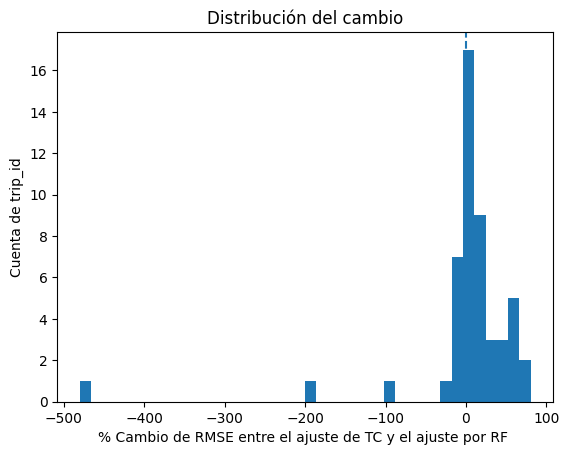

In [5]:
# Convertimos las variables al tipo de dato adecuado 
for c in ["real_trip_time_minutes", "random_forest", "median_ensemble"]:
    work[c] = pd.Series(work[c]).astype("float64")  

y_validation=work['real_trip_time_minutes']
y_validation_pred=work['random_forest']

# Calculamos los errores cuadráticos para 
work["sq_err_rf"] = (work["real_trip_time_minutes"] - work["random_forest"]) ** 2
work["sq_err_med"] = (work["real_trip_time_minutes"] - work["median_ensemble"]) ** 2

# Agrupamos y evaluamos el RMSE 
rmse_df = (
    work.groupby("trip_id", sort=False)
        .agg(
            rmse_rf=("sq_err_rf", lambda x: np.sqrt(x.mean())),
            rmse_med=("sq_err_med", lambda x: np.sqrt(x.mean())),
            n=("sq_err_rf", "size"),
        )
        .reset_index()
)

# Calculamos el cambio vs el ajuste generado sobre el valor ajustado por el RF 
rmse_df["pct_improvement"] = np.where(
    rmse_df["rmse_rf"] == 0,
    np.nan,
    (rmse_df["rmse_rf"] - rmse_df["rmse_med"]) / rmse_df["rmse_rf"] * 100
)

# Imprimimos resumen rápido 
print("Viajes distintos:", len(rmse_df))
print("Porcentaje donde se mejora la métrica RMSE:", (rmse_df["pct_improvement"] > 0).mean())
print("Mediana % del cambio:", rmse_df["pct_improvement"].median())
print("Promedio % del cambio:", rmse_df["pct_improvement"].mean())
print("Max % del cambio:", rmse_df["pct_improvement"].max())


# Histograma de resultados
vals = rmse_df["pct_improvement"].dropna()
plt.hist(vals, bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("% Cambio de RMSE entre el ajuste de TC y el ajuste por RF ")
plt.ylabel("Cuenta de trip_id")
plt.title("Distribución del cambio")
plt.show()


Por otro lado, generamos una impresión general de las métricas de R2 y RMSE aplicadas sobre la totalidad de los datos

In [6]:
# Definimos función de éxito en caso de predicción por debajo de los 10 min
def success_rate(y_true, y_pred, tol_minutes=10):
    """
    Success if:
      - not late: y_true <= y_pred
      - and not > tol_minutes early: (y_pred - y_true) <= tol_minutes
    Returns fraction in [0, 1].
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = (y_true <= y_pred) & ((y_pred - y_true) <= tol_minutes)
    return ok.mean()

# Función de uso de varias métricas 
def metrics_df(df, y_true_col, y_pred_col, tol_minutes=10):
    y_true = df[y_true_col].to_numpy(dtype=float)
    y_pred = df[y_pred_col].to_numpy(dtype=float)
    return pd.Series({
        "success_rate": success_rate(y_true, y_pred, tol_minutes=tol_minutes),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "n": len(df),
    })

# Generamos función para agrupar por trip_id para hacer la cuenta final 
def evaluate_overall_and_by_trip(df, y_true_col, y_pred_col, trip_col="trip_id", tol_minutes=10):
    overall = metrics_df(df, y_true_col, y_pred_col, tol_minutes=tol_minutes)
    by_trip = (
        df.groupby(trip_col, sort=False)
          .apply(lambda g: metrics_df(g, y_true_col, y_pred_col, tol_minutes=tol_minutes))
          .reset_index()
    )
    return overall, by_trip

In [7]:
overall_rf, by_trip_rf = evaluate_overall_and_by_trip(
    work,
    y_true_col="real_trip_time_minutes",
    y_pred_col="random_forest",
    trip_col="trip_id",
    tol_minutes=10
)

overall_bench, by_trip_bench = evaluate_overall_and_by_trip(
    work,
    y_true_col="real_trip_time_minutes",
    y_pred_col="estimated_trip_time_minutes",
    trip_col="trip_id",
    tol_minutes=10
)

overall_tc, by_trip_tc = evaluate_overall_and_by_trip(
    work,
    y_true_col="real_trip_time_minutes",
    y_pred_col="median_ensemble",
    trip_col="trip_id",
    tol_minutes=10
)

print('Se imprime el desempeño del ajuste de RF:')
print(overall_rf)

print('Se imprime el desempeño del estimado del benchmark (gmaps):')
print(overall_bench)

print('Se imprime el desempeño del ajuste de TC:')
print(overall_tc)

Se imprime el desempeño del ajuste de RF:
success_rate       0.364261
rmse              77.910619
r2                 0.917079
n               5529.000000
dtype: float64
Se imprime el desempeño del estimado del benchmark (gmaps):
success_rate       0.331525
rmse              79.878767
r2                 0.912837
n               5529.000000
dtype: float64
Se imprime el desempeño del ajuste de TC:
success_rate       0.305661
rmse              73.784186
r2                 0.925630
n               5529.000000
dtype: float64


A su vez, generamos un gráfico para evaluar la relación entre el valor real del tiempo del viaje

Text(0, 0.5, 'tiempo previsto \n (minutos)')

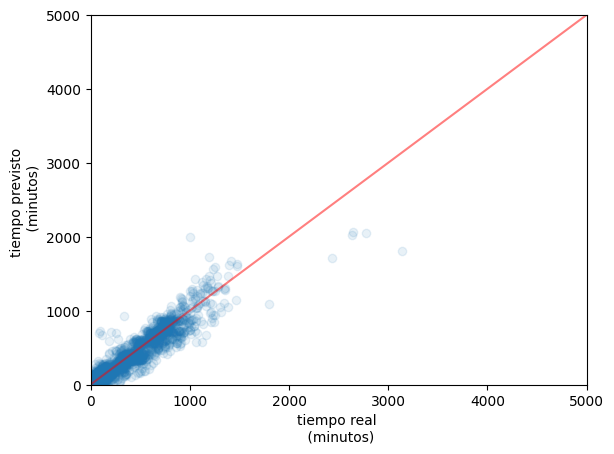

In [8]:
# Prediction over validation
plt.scatter(y_validation, med_preds, alpha=0.1)

xpoints = np.array([0, 100000])
ypoints = np.array([0, 100000])

plt.plot(xpoints, ypoints, color='red', alpha=0.5)
plt.xlim(0,5000)
plt.ylim(0,5000)

plt.xlabel('tiempo real \n (minutos)')
plt.ylabel('tiempo previsto \n (minutos)')

Por último, graficamos el score the R2 (por inviabilidad de usar el RMSE vs la cuenta de cada trip_id)

In [9]:
# Traemos la cuenta total de los viajes, de la ejecución previa de TC 
trip_kountz=pd.read_csv('trip_kounts.csv')

# Aprovechamos para traer la cuenta de viajes totales que se encuentran dentro 
# del conjunto de validación 
claves=list(set(results_temp.trip_id))
proporcion = (trip_kountz['count'][trip_kountz['trip_id'].isin(claves)].sum()/ \
    trip_kountz['count'].sum())*100
print("La cantidad de viajes representados en los ID's analizados es "+str(round(proporcion,2))+'%' )

# Juntamos la agrupación y cálculo de las métricas con respecto a los trip counts
metrics_tc = by_trip_tc.merge(trip_kountz,how='left',on='trip_id')

La cantidad de viajes representados en los ID's analizados es 19.83%


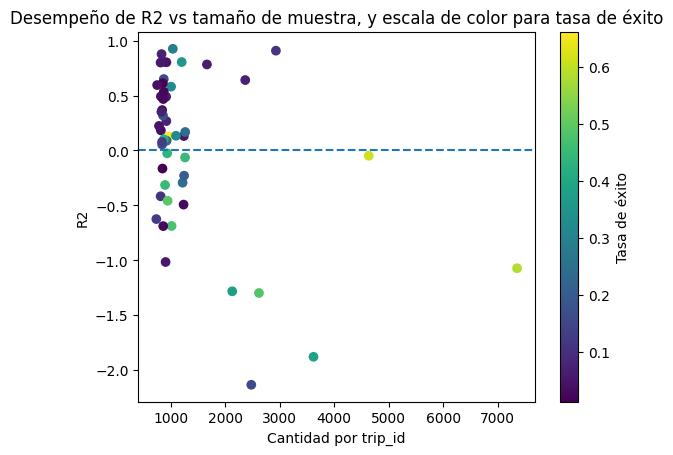

In [10]:
d = metrics_tc.copy()  # <-- your dataframe name here
d = d.dropna(subset=["count", "r2", "success_rate"])

plt.scatter(d["count"], d["r2"], c=d["success_rate"])
plt.colorbar(label="Tasa de éxito")
plt.axhline(0, linestyle="--")
plt.xlabel("Cantidad por trip_id")
plt.ylabel("R2")
plt.title("Desempeño de R2 vs tamaño de muestra, y escala de color para tasa de éxito")
plt.show()